In [32]:
import os

import data_util
import duckdb
import plot_util
import pyarrow.parquet as pq
import seaborn as sns
import wandb


In [33]:
data_root = os.path.abspath("../data/wandb")
group = "1706711470604_brpq_pretraining"
project = "ethanluoyc/c2"

if not os.path.exists(os.path.join(data_root, group)):
    api = wandb.Api()
    runs = api.runs(project, filters={"group": group})
    assert runs
    save_dir = os.path.join(data_root, group)
    os.makedirs(save_dir, exist_ok=True)
    for run in runs:
        table = data_util.to_arrow_table(run, save_metadata=True)
        save_path = os.path.join(save_dir, f"{run.id}.parquet")
        print("Saving", save_path)
        pq.write_table(table, save_path)

file_glob = os.path.join(data_root, group, "*.parquet")
meta = data_util.read_wandb_metadata(file_glob)
metrics = data_util.read_wandb_history(file_glob)
measurements = duckdb.from_df(meta.loc[:, ["id", *meta.attrs["sweep_vars"]]]).join(
    metrics, "id"
)


ValueError: Could not find project c2

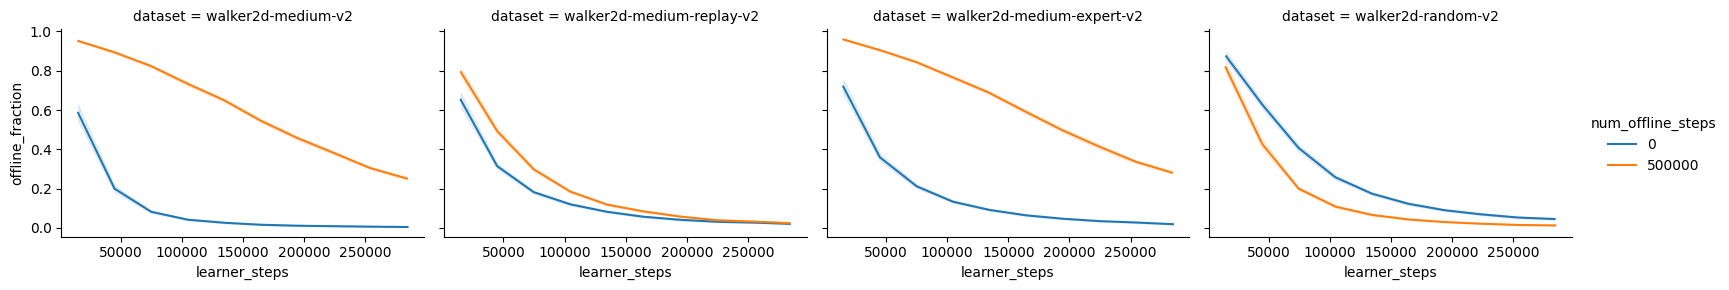

In [31]:
data = measurements.project(
    """
"config.dataset.name" as dataset,
"config.num_offline_steps" as num_offline_steps,
"learner/learner_steps" as learner_steps,
(1 - "learner/online_fraction") as offline_fraction,
"""
).filter("offline_fraction is not NULL")

g = sns.FacetGrid(
    data.df(),
    col="dataset",
    hue="num_offline_steps",
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)
g.map(plot_util.smoothed_lineplot, "learner_steps", "offline_fraction")
g.add_legend()

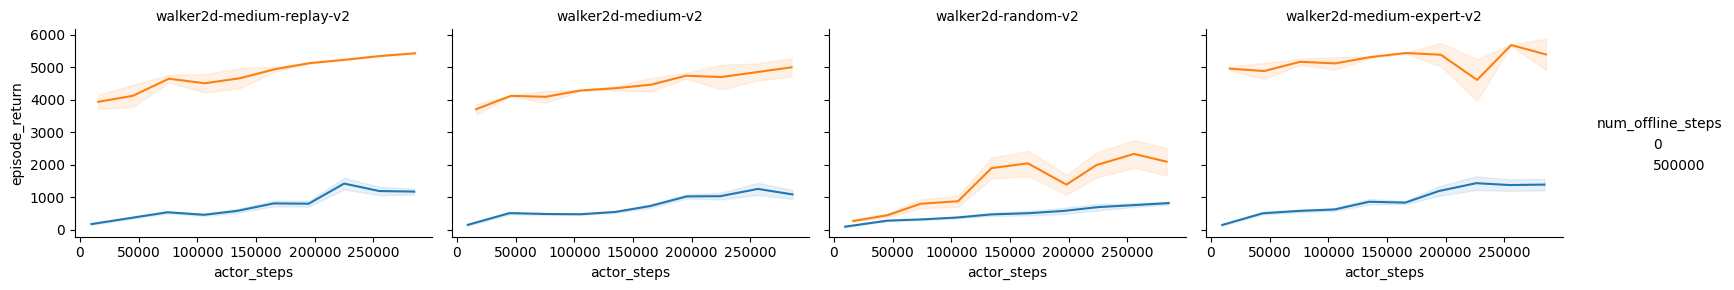

In [32]:
data = measurements.project(
    """
"config.dataset.name" as dataset,
"config.num_offline_steps" as num_offline_steps,
"actor/actor_steps" as actor_steps,
"actor/episode_return" as episode_return,
"""
).filter("actor_steps is not NULL")

g = sns.FacetGrid(
    data.df(),
    col="dataset",
    hue="num_offline_steps",
    sharey='row',
    sharex=True,
    aspect=1/0.75,
)
g.set_titles("{col_name}")
g.add_legend()
g.map(plot_util.smoothed_lineplot, "actor_steps", "episode_return")
